In [4]:
!pip install unidecode


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\markd\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
import random
import time 
from unidecode import unidecode

In [18]:
teams = [
    "atl", "bos", "brk", "cho", "chi", "cle", "dal", "den", "det", "gsw",
    "hou", "ind", "lac", "lal", "mem", "mia", "mil", "min", "nop", "nyk",
    "okc", "orl", "phi", "pho", "por", "sac", "sas", "tor", "uta", "was"
]

In [31]:
seasons = ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
print(seasons)

['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


In [10]:
stats = [
    'FG','FGA','FG%',
    '3P','3PA','3P%',
    'FT','FTA','FT%',
    'ORB','TRB','AST',
    'STL','BLK','TOV','PF'
]

# Seperate Team vs opponent stats
tm_stats_dict = {stat: 'Tm_' + str(stat) for stat in stats}

opp_stats_dict = {stat + '.1': 'Opp_' + str(stat) for stat in stats}

In [20]:
nba_df = pd.DataFrame()

for season in seasons:
    
    for team in teams:
        url = 'https://www.basketball-reference.com/teams/' + team + '/' + season + '/gamelog/'
        print(url)

        # Get game stats from table
        team_df = pd.read_html(url, header=1, attrs={'id':'team_game_log_reg'})[0]

        # Drop rows where 'Rk' is null or equal to 'Rk'
        team_df = team_df[(team_df['Rk'].str != '') & (team_df['Rk'].str.isnumeric())]

        team_df = team_df.drop(columns=['Rk'])

        team_df = team_df.rename(columns={'Unnamed: 3':'Home', 'Tm':'Tm_Pts', 'Opp.1':'Opp_Pts'})
        team_df = team_df.rename(columns=tm_stats_dict)
        team_df = team_df.rename(columns=opp_stats_dict)

        team_df['Home'] = team_df['Home'].apply(lambda x: 0 if x == '@' else 1)

        team_df.insert(loc=0, column='Season', value=season)
        team_df.insert(loc=1, column='Team', value=team.upper())

        nba_df = pd.concat([nba_df, team_df], ignore_index=True)

        time.sleep(random.randint(4,6))


https://www.basketball-reference.com/teams/atl/2015/gamelog/
https://www.basketball-reference.com/teams/bos/2015/gamelog/
https://www.basketball-reference.com/teams/brk/2015/gamelog/
https://www.basketball-reference.com/teams/cho/2015/gamelog/
https://www.basketball-reference.com/teams/chi/2015/gamelog/
https://www.basketball-reference.com/teams/cle/2015/gamelog/
https://www.basketball-reference.com/teams/dal/2015/gamelog/
https://www.basketball-reference.com/teams/den/2015/gamelog/
https://www.basketball-reference.com/teams/det/2015/gamelog/
https://www.basketball-reference.com/teams/gsw/2015/gamelog/
https://www.basketball-reference.com/teams/hou/2015/gamelog/
https://www.basketball-reference.com/teams/ind/2015/gamelog/
https://www.basketball-reference.com/teams/lac/2015/gamelog/
https://www.basketball-reference.com/teams/lal/2015/gamelog/
https://www.basketball-reference.com/teams/mem/2015/gamelog/
https://www.basketball-reference.com/teams/mia/2015/gamelog/
https://www.basketball-r

In [21]:
print(nba_df)

      Season Team Gtm        Date  Home  Opp Rslt Tm_Pts Opp_Pts   OT  ...  \
0       2015  ATL   1  2014-10-29     0  TOR    L    102     109  NaN  ...   
1       2015  ATL   2  2014-11-01     1  IND    W    102      92  NaN  ...   
2       2015  ATL   3  2014-11-05     0  SAS    L     92      94  NaN  ...   
3       2015  ATL   4  2014-11-07     0  CHO    L    119     122  2OT  ...   
4       2015  ATL   5  2014-11-08     1  NYK    W    103      96  NaN  ...   
...      ...  ...  ..         ...   ...  ...  ...    ...     ...  ...  ...   
23953   2024  WAS  78  2024-04-05     1  POR    L    102     108  NaN  ...   
23954   2024  WAS  79  2024-04-07     0  TOR    L    122     130  NaN  ...   
23955   2024  WAS  80  2024-04-09     0  MIN    L    121     130  NaN  ...   
23956   2024  WAS  81  2024-04-12     1  CHI    L    127     129  NaN  ...   
23957   2024  WAS  82  2024-04-14     0  BOS    L    122     132  NaN  ...   

      Opp_FTA Opp_FT% Opp_ORB DRB.1 Opp_TRB Opp_AST Opp_STL Opp

In [24]:
nba_df.to_csv('nba.csv', index=False)

In [28]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("nba.csv")

# Rename columns
df.rename(columns={"Gtm": "G", "Rslt": "W/L"}, inplace=True)

# Stats to keep
stats = [
    'FG','FGA','FG%',
    '3P','3PA','3P%',
    'FT','FTA','FT%',
    'ORB','TRB','AST',
    'STL','BLK','TOV','PF'
]

# Build full list of columns to keep
base_columns = ['Season', 'Team', 'G', 'Date', 'Home', 'Opp', 'W/L', 'Tm_Pts', 'Opp_Pts']
tm_stats = ['Tm_' + stat for stat in stats]
opp_stats = ['Opp_' + stat for stat in stats]
columns_to_keep = base_columns + tm_stats + opp_stats

# Filter the DataFrame
filtered_df = df[columns_to_keep]

# Save to new CSV
filtered_df.to_csv("nba_filtered_stats.csv", index=False)

print("Filtered data saved to 'nba_filtered_stats.csv'")


Filtered data saved to 'nba_filtered_stats.csv'


In [29]:
print(filtered_df)

       Season Team   G        Date  Home  Opp W/L  Tm_Pts  Opp_Pts  Tm_FG  \
0        2015  ATL   1  2014-10-29     0  TOR   L     102      109     40   
1        2015  ATL   2  2014-11-01     1  IND   W     102       92     35   
2        2015  ATL   3  2014-11-05     0  SAS   L      92       94     38   
3        2015  ATL   4  2014-11-07     0  CHO   L     119      122     43   
4        2015  ATL   5  2014-11-08     1  NYK   W     103       96     33   
...       ...  ...  ..         ...   ...  ...  ..     ...      ...    ...   
23953    2024  WAS  78  2024-04-05     1  POR   L     102      108     38   
23954    2024  WAS  79  2024-04-07     0  TOR   L     122      130     42   
23955    2024  WAS  80  2024-04-09     0  MIN   L     121      130     44   
23956    2024  WAS  81  2024-04-12     1  CHI   L     127      129     45   
23957    2024  WAS  82  2024-04-14     0  BOS   L     122      132     49   

       ...  Opp_FT  Opp_FTA  Opp_FT%  Opp_ORB  Opp_TRB  Opp_AST  Opp_STL  \

In [45]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score

# --- Load your cleaned dataframe here ---
df = pd.read_csv("nba_filtered_stats.csv")

# --- Basic Minutes per game assumption ---
# You can update this if you have actual minute data
MINUTES = 48 

# --- Calculate Possessions ---
df["Poss"] = df["Tm_FGA"] - df["Tm_ORB"] + 0.4 * df["Tm_FTA"] + df["Tm_TOV"]

# --- Offensive & Defensive Ratings ---
df["OffRtg"] = (df["Tm_Pts"] / df["Poss"]) * 100
df["DefRtg"] = (df["Opp_Pts"] / df["Poss"]) * 100
df["NetRtg"] = df["OffRtg"] - df["DefRtg"]

# --- Pace ---
df["Pace"] = (df["Poss"] / MINUTES) * 48

# --- League averages (can be refined weekly) ---
league_avg_pace = df["Pace"].mean()
league_avg_off_rtg = df["OffRtg"].mean()
league_avg_def_rtg = df["DefRtg"].mean()

# --- For simplicity, assume opponent pace = team pace ---
df["EPace"] = df["Pace"] - (league_avg_pace - df["Pace"])

# --- Expected Score (custom formula) ---
df["Tm_Score"] = ((df["OffRtg"] - (league_avg_off_rtg - df["DefRtg"])) / 100) * df["EPace"]
df["Opp_Score"] = ((df["DefRtg"] - (league_avg_def_rtg - df["OffRtg"])) / 100) * df["EPace"]

# --- Spread and Total ---
df["Spread"] = df["Opp_Score"] - df["Tm_Score"]
df["Total"] = df["Opp_Score"] + df["Tm_Score"]

# --- Target for regression ---
spread_target = df["Spread"]
total_target = df["Total"]

# --- Target for classification: over/under 220 for example ---
df["OverUnder"] = (df["Total"] > 220).astype(int)

# --- Features for prediction ---
features = df[[
    "Tm_FGA", "Tm_FTA", "Tm_TOV", "Tm_ORB", "Pace", "OffRtg", "DefRtg", "NetRtg"
]]

# --- Train/Test Split ---
X_train, X_test, y_spread_train, y_spread_test = train_test_split(features, spread_target, test_size=0.2, random_state=42)
_, _, y_total_train, y_total_test = train_test_split(features, total_target, test_size=0.2, random_state=42)
_, _, y_over_train, y_over_test = train_test_split(features, df["OverUnder"], test_size=0.2, random_state=42)

# --- Model to Predict Spread ---
spread_model = LinearRegression()
spread_model.fit(X_train, y_spread_train)
spread_pred = spread_model.predict(X_test)
print("Spread MAE:", mean_absolute_error(y_spread_test, spread_pred))

# --- Model to Predict Total ---
total_model = LinearRegression()
total_model.fit(X_train, y_total_train)
total_pred = total_model.predict(X_test)
print("Total MAE:", mean_absolute_error(y_total_test, total_pred))

# --- Model to Predict Over/Under ---
over_model = LogisticRegression(max_iter=1000)
over_model.fit(X_train, y_over_train)
over_pred = over_model.predict(X_test)
print("Over/Under Accuracy:", accuracy_score(y_over_test, over_pred))


Spread MAE: 9.923162012691868e-15
Total MAE: 2.6749748179921227
Over/Under Accuracy: 0.9847662771285476


In [49]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\markd\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Spread MAE: 0.000
Total MAE: 2.726
Over/Under Accuracy: 0.987


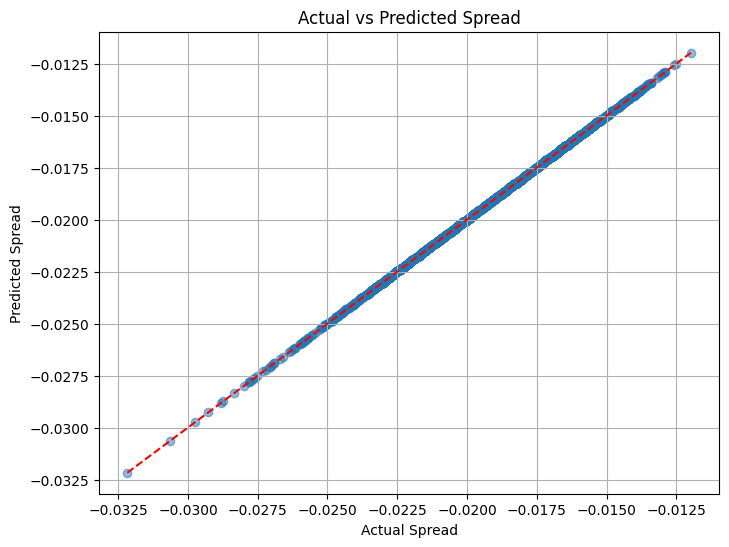

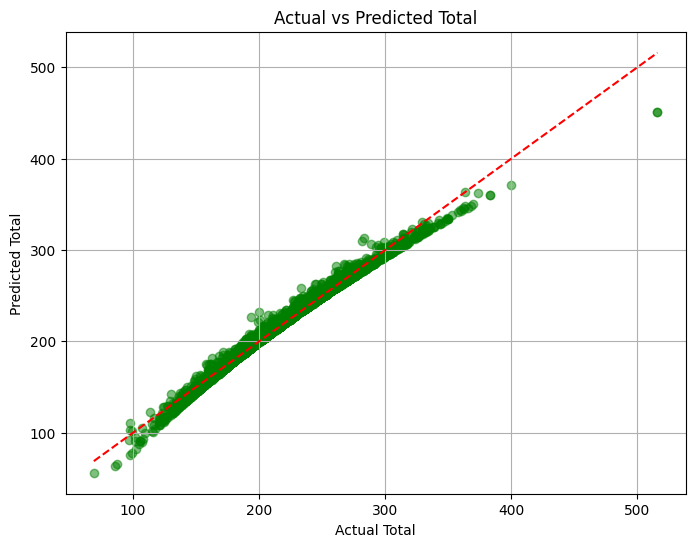

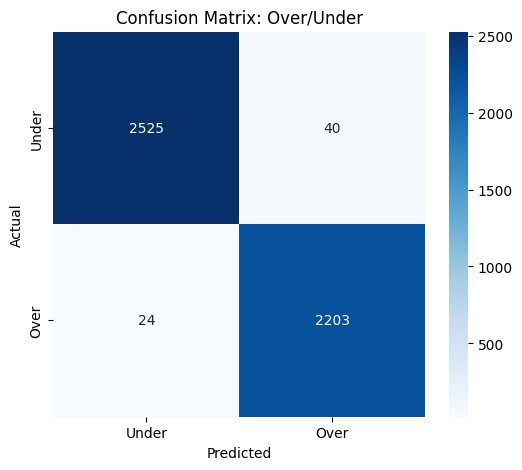

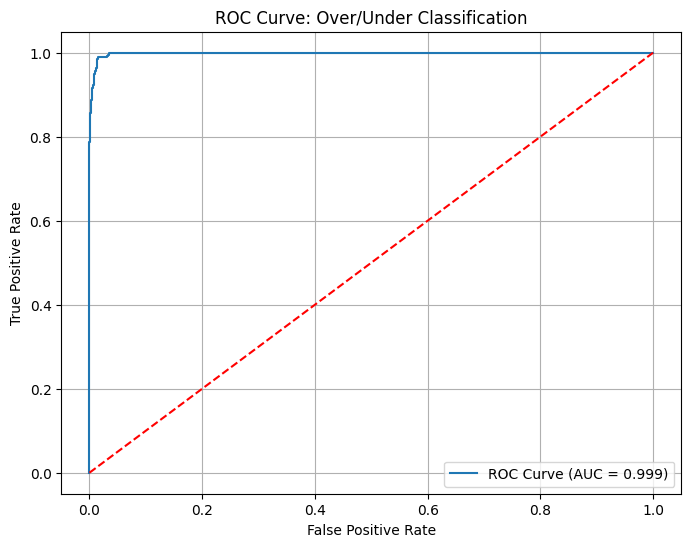

In [50]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load your cleaned dataframe ---
df = pd.read_csv("nba_filtered_stats.csv")

MINUTES = 48  
# Calculate possessions
df["Poss"] = df["Tm_FGA"] - df["Tm_ORB"] + 0.4 * df["Tm_FTA"] + df["Tm_TOV"]

# Offensive & Defensive Ratings
df["OffRtg"] = (df["Tm_Pts"] / df["Poss"]) * 100
df["DefRtg"] = (df["Opp_Pts"] / df["Poss"]) * 100
df["NetRtg"] = df["OffRtg"] - df["DefRtg"]

# Pace
df["Pace"] = (df["Poss"] / MINUTES) * 48

# League averages
league_avg_pace = df["Pace"].mean()
league_avg_off_rtg = df["OffRtg"].mean()
league_avg_def_rtg = df["DefRtg"].mean()

# Opponent pace assumed equal to team pace for simplicity
df["EPace"] = df["Pace"] - (league_avg_pace - df["Pace"])

# Expected scores
df["Tm_Score"] = ((df["OffRtg"] - (league_avg_off_rtg - df["DefRtg"])) / 100) * df["EPace"]
df["Opp_Score"] = ((df["DefRtg"] - (league_avg_def_rtg - df["OffRtg"])) / 100) * df["EPace"]

# Spread and total
df["Spread"] = df["Tm_Score"] - df["Opp_Score"]
df["Total"] = df["Tm_Score"] + df["Opp_Score"]

# Over/Under classification target
df["OverUnder"] = (df["Total"] > 220).astype(int)

# Features
features = df[[
    "Tm_FGA", "Tm_FTA", "Tm_TOV", "Tm_ORB", "Pace", "OffRtg", "DefRtg", "NetRtg"
]]

# Clean data: drop any missing values
data = pd.concat([features, df["Spread"], df["Total"], df["OverUnder"]], axis=1).dropna()

features_clean = data[features.columns]
spread_target = data["Spread"]
total_target = data["Total"]
over_target = data["OverUnder"]

# Train/test split with stratification on over/under
X_train, X_test, y_spread_train, y_spread_test, y_total_train, y_total_test, y_over_train, y_over_test = train_test_split(
    features_clean, spread_target, total_target, over_target,
    test_size=0.2,
    random_state=42,
    stratify=over_target
)

# --- Train Spread model ---
spread_model = LinearRegression()
spread_model.fit(X_train, y_spread_train)
spread_pred = spread_model.predict(X_test)

print(f"Spread MAE: {mean_absolute_error(y_spread_test, spread_pred):.3f}")

# --- Train Total model ---
total_model = LinearRegression()
total_model.fit(X_train, y_total_train)
total_pred = total_model.predict(X_test)

print(f"Total MAE: {mean_absolute_error(y_total_test, total_pred):.3f}")

# --- Train Over/Under classification model ---
over_model = LogisticRegression(max_iter=1000)
over_model.fit(X_train, y_over_train)
over_pred = over_model.predict(X_test)

print(f"Over/Under Accuracy: {accuracy_score(y_over_test, over_pred):.3f}")

# --- Plot Actual vs Predicted for Spread ---
plt.figure(figsize=(8,6))
plt.scatter(y_spread_test, spread_pred, alpha=0.5)
plt.plot([y_spread_test.min(), y_spread_test.max()], [y_spread_test.min(), y_spread_test.max()], 'r--')
plt.xlabel("Actual Spread")
plt.ylabel("Predicted Spread")
plt.title("Actual vs Predicted Spread")
plt.grid(True)
plt.show()

# --- Plot Actual vs Predicted for Total ---
plt.figure(figsize=(8,6))
plt.scatter(y_total_test, total_pred, alpha=0.5, color='green')
plt.plot([y_total_test.min(), y_total_test.max()], [y_total_test.min(), y_total_test.max()], 'r--')
plt.xlabel("Actual Total")
plt.ylabel("Predicted Total")
plt.title("Actual vs Predicted Total")
plt.grid(True)
plt.show()

# --- Plot confusion matrix for Over/Under ---
cm = confusion_matrix(y_over_test, over_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Under", "Over"], yticklabels=["Under", "Over"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Over/Under")
plt.show()

# --- Plot ROC curve for Over/Under ---
y_over_prob = over_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_over_test, y_over_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Over/Under Classification")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [60]:
import pandas as pd

# Load your NBA dataset
df = pd.read_csv("nba_filtered_stats.csv")

# Create Total column by summing team and opponent points
df['Total'] = df['Tm_Pts'] + df['Opp_Pts']

df['Spread'] = df['Tm_Pts'] - df['Opp_Pts']

df.to_csv("nbastats.csv", index=False)


In [93]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Load and preprocess data
df = pd.read_csv("nbastats.csv")
df["Total"] = df["Tm_Pts"] + df["Opp_Pts"]
df["Spread"] = df["Tm_Pts"] - df["Opp_Pts"]

# Over/Under threshold (average Total)
threshold = df["Total"].mean()
print(f"Using average Total as Over/Under threshold: {threshold:.2f}")

df["OverUnder"] = (df["Total"] > threshold).astype(int)

# Features for Over/Under classification
features_ou = ["Spread", "Total"]
X_ou = df[features_ou]
y_ou = df["OverUnder"]

# Features for Spread regression (exclude Spread)
features_sp = ["Total"]
X_sp = df[features_sp]
y_sp = df["Spread"]

# Split data
X_train_ou, X_test_ou, y_train_ou, y_test_ou = train_test_split(X_ou, y_ou, test_size=0.2, random_state=42)
X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(X_sp, y_sp, test_size=0.2, random_state=42)

# Over/Under classifier pipeline
clf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
clf_pipe.fit(X_train_ou, y_train_ou)

# Spread regressor pipeline
spread_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
spread_pipe.fit(X_train_sp, y_train_sp)

# New games to predict
new_games = [
    ["Celtics vs Hawks", -6.5, 220.5],
    ["Lakers vs Nuggets", 2.5, 224.0],
    ["Heat vs Bulls", -1.0, 217.5]
]

X_new = pd.DataFrame(new_games, columns=["Game", "Spread", "Total"])

# Predict Over/Under
y_new_ou_pred = clf_pipe.predict(X_new[features_ou])

# Predict Spread — only use Total, NOT Spread as input
X_new_spread = X_new[features_sp]
spread_preds = spread_pipe.predict(X_new_spread)

# Add predictions to DataFrame
X_new["Prediction_OverUnder"] = ["Over" if p == 1 else "Under" for p in y_new_ou_pred]
X_new["PredictedSpread"] = spread_preds

print("\nNBA Game Predictions:")
print(X_new[["Game", "Spread", "Total", "Prediction_OverUnder", "PredictedSpread"]])


Using average Total as Over/Under threshold: 217.68

NBA Game Predictions:
                Game  Spread  Total Prediction_OverUnder  PredictedSpread
0   Celtics vs Hawks    -6.5  220.5                 Over         0.083930
1  Lakers vs Nuggets     2.5  224.0                 Over         0.088215
2      Heat vs Bulls    -1.0  217.5                Under         0.080256
